**Goal:** build and read the five plots from the concept catalogue -- scatter, Pareto, time-dependent
line, parallel coordinates, and star/radar -- and practice picking the right one for a question. Pairs
with the concept note
[Visual Methods for One & Two Variables](l09_concept_eda_visual_methods.qmd).

> This page is the read-only view. To run the lab, open the notebook (`l09_lab_eda_visual_methods.ipynb`)
> -- in Colab via the badge on the concept page, or locally. Every text output below comes from actually
> running the cells; the plots render live in the notebook.

## Prerequisites & Setup

Run the setup cells first. Three small datasets, all deterministic:

- **Palmer Penguins** (Gorman, Williams & Fraser 2014, *PLoS ONE*; CC0 public domain), bundled as
  `data/penguins.csv` with a seaborn-data fallback -- for the scatter, parallel-coordinates, and radar.
- a tiny **fixed** table of utility complaints by type -- for the Pareto.
- a **fixed, formula-built** monthly series (no random numbers) -- for the time plot.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + the three datasets (all deterministic; no seed needed)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Palmer Penguins -- Gorman, Williams & Fraser (2014), PLoS ONE; CC0 public domain
LOCAL = "data/penguins.csv"
URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL)

# Fixed frame 1: utility complaints by type (for the Pareto)
complaints = pd.Series(
    {"Billing": 210, "Outage": 120, "Meter reading": 60,
     "New service": 40, "Tree trimming": 20, "Other": 10})

# Fixed frame 2: a deterministic simulated monthly PM2.5 series (level + trend + season; NO randomness)
months = pd.date_range("2023-01-01", periods=24, freq="MS")
t = np.arange(24)
pm25 = pd.Series(np.round(8.0 + 0.05 * t + 2.5 * np.sin(2 * np.pi * t / 12), 1), index=months)

print("penguins:", penguins.shape, "| complaints:", complaints.shape, "| months:", pm25.shape)

penguins: (344, 7) | complaints: (6,) | months: (24,)


<details><summary>Expected Output</summary>

~~~text
penguins: (344, 7) | complaints: (6,) | months: (24,)
~~~
</details>

## Step 1: Scatter -- Do Two Numeric Variables Move Together?

One point per penguin, colored by species. Read it with the four words from the concept: direction, form,
strength, unusual points.

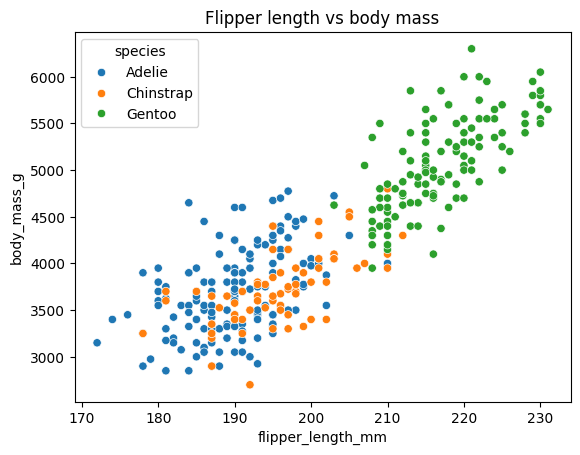

In [3]:
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", hue="species")
plt.title("Flipper length vs body mass")
plt.show()

<details><summary>Expected Output</summary>

*(A scatter rising from lower-left to upper-right in a tight band -- **positive**, **strong**, roughly
**linear**. The Gentoo points form a separate cloud at the top right: high flipper length and high mass,
the species mixture from L08 now visible in two dimensions. The qualitative read is all we make here; the
*number* (correlation) is L19.)*
</details>

## Step 2: Pareto -- Which Few Categories Dominate?

Sort the category counts largest-to-smallest and track the running cumulative percentage. The cumulative
column is what turns a bar chart into a Pareto.

In [4]:
counts = complaints.sort_values(ascending=False)
pareto = pd.DataFrame({"count": counts,
                       "cumulative_pct": (counts.cumsum() / counts.sum() * 100).round(1)})
print(pareto)

               count  cumulative_pct
Billing          210            45.7
Outage           120            71.7
Meter reading     60            84.8
New service       40            93.5
Tree trimming     20            97.8
Other             10           100.0


<details><summary>Expected Output</summary>

~~~text
               count  cumulative_pct
Billing          210            45.7
Outage           120            71.7
Meter reading     60            84.8
New service       40            93.5
Tree trimming     20            97.8
Other             10           100.0
~~~
*(The cumulative line crosses 80% at the third row: the **vital few** -- Billing, Outage, Meter reading --
are ~85% of all complaints; the other three are the trivial many.)*
</details>

Now draw it. **Uncomment and complete** the cumulative-percentage blank, then run:

In [5]:
# Uncomment and fill the one ____ blank (the running cumulative percentage), then run:
# fig, ax = plt.subplots()
# ax.bar(counts.index, counts.values)                 # sorted bars
# ax2 = ax.twinx()
# ax2.plot(counts.index, ____, color="red", marker="o")   # counts.cumsum() / counts.sum() * 100
# ax2.axhline(80, ls="--", color="gray")              # the 80% line
# ax.set_ylabel("complaints"); ax2.set_ylabel("cumulative %")
# plt.title("Pareto: complaints by type"); plt.show()

<details><summary>Expected Output</summary>

*(Descending blue bars with a rising red cumulative line; the line crosses the dashed 80% mark at the
third bar (Meter reading), so the first three bars are the vital few.)*
</details>

## Step 3: Time-Dependent Plot -- How Does It Move Over Time?

Plot the monthly series in time order and read it for level, trend, seasonality, and spikes.

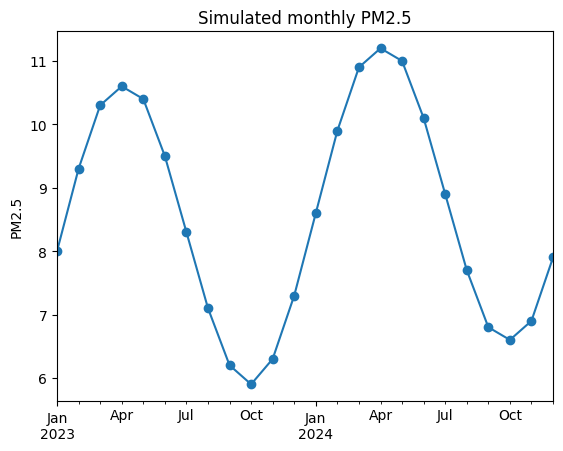

In [6]:
pm25.plot(marker="o")
plt.title("Simulated monthly PM2.5")
plt.ylabel("PM2.5")
plt.show()

**Read it:** a wave that repeats about every 12 months (**seasonality**) while drifting gently upward
(**trend**). Confirm the trend with two numbers -- the average of the first year versus the second:

In [7]:
print(f"first 12-mo mean: {pm25[:12].mean():.2f}")
print(f"last  12-mo mean: {pm25[12:].mean():.2f}")

first 12-mo mean: 8.27
last  12-mo mean: 8.88


<details><summary>Expected Output</summary>

~~~text
first 12-mo mean: 8.27
last  12-mo mean: 8.88
~~~
*(The second year averages higher than the first -- the upward trend, as a number. Putting a precise trend
and seasonal component on a series -- decomposition -- is L17; here we just see them.)*
</details>

## Your Turn

### Exercise 1 -- Parallel Coordinates: Many Variables at Once

Min-max scale the four numeric measurements to 0-1 (so the axes are comparable) and draw a
**parallel-coordinates** plot colored by species. Describe which species separates.

**Hint:** `from pandas.plotting import parallel_coordinates`; scale each column with
`(col - col.min()) / (col.max() - col.min())`; drop NaNs first.

In [8]:
# TODO: your code here (scale the 4 measurements, then parallel_coordinates(..., "species"))

<details><summary>Expected Output</summary>

*(The Gentoo lines sweep low on bill depth but high on flipper length and body mass, separating cleanly
from the overlapping Adelie and Chinstrap lines -- four variables and three groups in one figure.)*
</details>

### Exercise 2 -- Star / Radar: Compare Group Profiles

Compute the mean of each measurement per species (`groupby`), min-max scale each measurement across the
three species, and read the three profiles. (Drawing a radar is fiddly in matplotlib; describing the
profiles from the scaled means table is enough.)

**Hint:** `penguins.groupby("species")[cols].mean()`, then scale each column to 0-1 across the three rows.

In [9]:
# TODO: your code here (groupby mean, scale, print the table)

<details><summary>Expected Output</summary>

~~~text
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species
Adelie               0.00           0.98               0.00         0.00
Chinstrap            1.00           1.00               0.22         0.02
Gentoo               0.87           0.00               1.00         1.00
~~~
*(Three different profiles, straight from the scaled table: Chinstrap is highest on bill length and bill
depth; Gentoo on flipper length and body mass; Adelie nearly ties Chinstrap on bill depth (0.98 vs 1.00)
but sits lowest on the other three. On a radar these draw three differently shaped polygons.)*
</details>

### Exercise 3 -- Which Plot Would You Use?

For each question, name the plot from the catalogue (no code needed):

1. "Of our 12 product categories, which few drive most of the returns?"
2. "Has website latency crept up over the last two years, and is it worse in some months?"
3. "Do heavier students also tend to be taller?"

<details><summary>One acceptable answer</summary>

1. **Pareto diagram** -- sorted bars plus the cumulative line show the vital few categories.
2. **Time-dependent line plot** -- trend (crept up?) and seasonality (worse some months?) are read by eye.
3. **Scatter plot** -- two numeric variables; read direction, form, and strength (the number is L19).
</details>

## Summary

- One question, one plot: scatter (two numerics move together?), Pareto (which few categories dominate?),
  time line (how does it move over time?), parallel coordinates / radar (many variables or group
  profiles).
- A **scatter** is read by eye -- direction, form, strength, unusual points -- before any number; Anscombe
  is why the picture comes first.
- A **Pareto** is a sorted bar chart *plus* a cumulative line; the line crossing ~80% names the vital few.
- A **time plot** shows level, trend, seasonality, and spikes at a glance; the precise decomposition is
  L17.
- **Parallel coordinates** and **radar** put many variables in one figure -- powerful for a handful of
  groups and axes, spaghetti beyond that. Next lesson (L10) runs the whole EDA loop on one dataset.